## 7: The hero in profile: SPP1 x CD44 across the strips

Observed L(r) vs the permutation envelope for the single strict hit. It rises above the null **only in the
infected strip** (seven consecutive radii); both controls stay inside. The envelope already accounts for
abundance, so this is the abundance-corrected, infection-specific evidence that a raw spatial scatter cannot
give (raw nearest-neighbour distances are actually shorter in a control strip, because it has more CD44).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle, ConnectionPatch
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FIG = ROOT / "results" / "figures"
DATA = ROOT / "data" / "processed"
print("root:", ROOT)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "dejavusans"
BG, CARD, TEAL, FAINT = "#0d0d0d", "#1a1a1a", "#1A7A7A", "#333333"
WHITE, MUTED, GREY = "#ffffff", "#c8c8c8", "#9a9a9a"
VERM, BLUE, GREEN = "#D55E00", "#0072B2", "#009E73"
STRIP = {"strip_1": BLUE, "strip_2": VERM, "strip_3": GREEN}
STRIP_LABEL = {"strip_1": "strip 1 (control)", "strip_2": "strip 2 (infected)", "strip_3": "strip 3 (control)"}

def cls(g):
    g = str(g)
    if g.startswith(("CXCL", "CCL", "CXCR", "CCR", "ACKR")): return "chemokine"
    if g.startswith(("OAS", "ISG", "IFIT", "MX", "IRF", "STAT1")): return "interferon"
    if g.startswith(("TNF", "IL")): return "cytokine/TNF"
    if g.startswith("FGF"): return "FGF/growth"
    if g.startswith(("COL", "FN1", "VIM", "SPARC", "THBS", "LAMA")): return "stromal/ECM"
    if g.startswith(("KRT", "SCGB", "EPCAM", "MUC")): return "epithelial"
    if g.startswith(("CD", "PDCD", "HLA", "B2M", "ICOS")): return "immune"
    return "other"

CLSCOL = {"chemokine": "#E69F00", "interferon": "#56B4E9", "cytokine/TNF": "#CC79A7",
          "FGF/growth": "#009E73", "stromal/ECM": "#D55E00", "epithelial": "#8c8c8c",
          "immune": "#F0E442", "other": "#B39DDB"}

def finish(fig, name):
    out = FIG / f"STIPPLE_{name}.png"
    fig.savefig(out, dpi=200, facecolor=BG)
    print("saved", out.name); plt.show()

root: C:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern


## 1: Layered CosMx output (FOV 16)
Raw morphology, vendor segmentation, and located transcripts over the same field of view, as an exploded
stack. Shows how segmentation compresses ~70k molecules into ~80 cells.

saved STIPPLE_layers.png


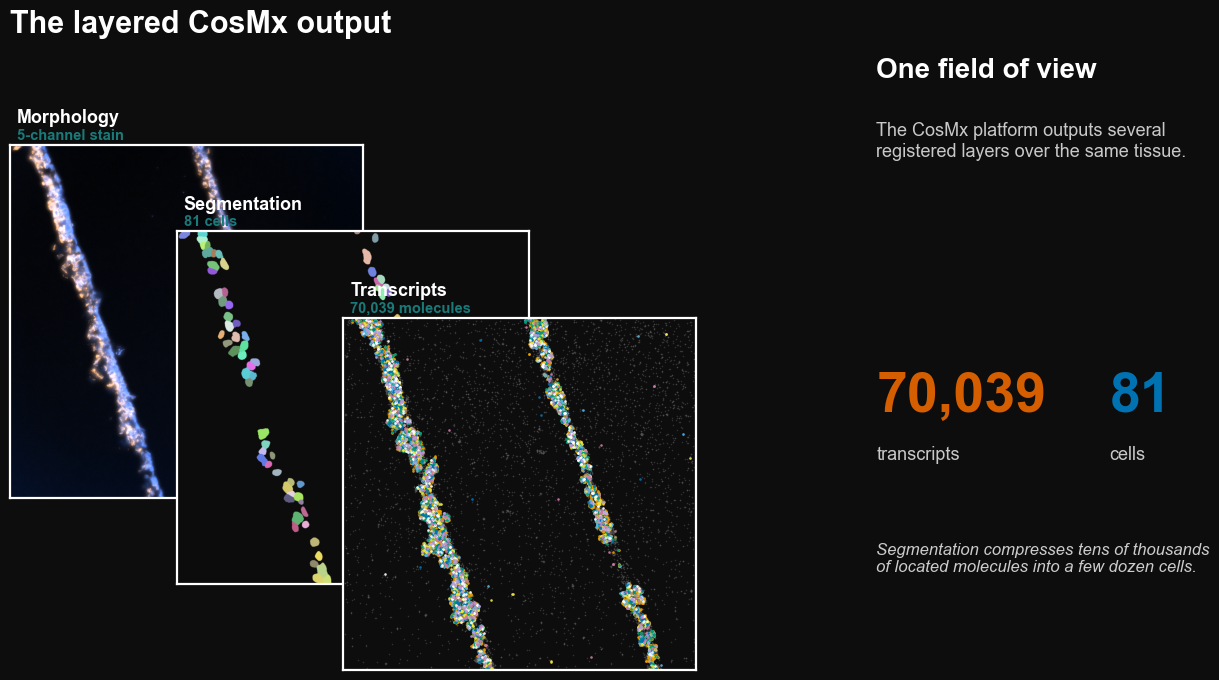

In [2]:
import spatialdata as sd, contextlib, io
with contextlib.redirect_stderr(io.StringIO()):
    sdata = sd.read_zarr(ROOT / "data" / "raw" / "Varsha_1234.zarr")
SUB = 3
img = np.asarray(sdata.images["16_image"].data[:, ::SUB, ::SUB]).astype(float)
lab = np.asarray(sdata.labels["16_labels"].data[::SUB, ::SUB])
pts = sdata.points["16_points"]; pts = pts.compute() if hasattr(pts, "compute") else pts
H, W = lab.shape

def norm(c):
    a, b = np.percentile(c, [1, 99.5]); return np.clip((c - a) / (b - a + 1e-9), 0, 1)
struct, nuc = norm(img[0]), norm(img[4])
morph = np.clip(np.stack([struct*.95+nuc*.05, struct*.55+nuc*.35, nuc*.95+struct*.1], -1)*1.15, 0, 1)
rng = np.random.default_rng(7); ncell = int(lab.max())
cols = rng.random((ncell+1, 3))*0.6+0.35; cols[0] = [.05, .05, .05]; seg = cols[lab]
top = pts.target.value_counts().head(8).index.tolist()
pal = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#CC79A7", "#FFFFFF", "#B39DDB"]
gc = dict(zip(top, pal))

fig = plt.figure(figsize=(13.33, 7.5), facecolor=BG)
h_frac = 0.47; w_frac = h_frac / (13.33/7.5); x0, y0 = 0.035, 0.30; dx, dy = 0.125, -0.115
panels = [("Morphology", "5-channel stain", morph, None), ("Segmentation", f"{ncell} cells", seg, None),
          ("Transcripts", f"{len(pts):,} molecules", None, "pts")]
for i, (nm, sub, rgb, kind) in enumerate(panels):
    ax = fig.add_axes([x0+i*dx, y0+i*dy, w_frac, h_frac]); ax.set_facecolor(BG)
    if kind == "pts":
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        o = pts[~pts.target.isin(top)]
        ax.scatter(o.x/SUB, o.y/SUB, s=1.2, c="#555", alpha=.5, lw=0, rasterized=True)
        for g in top:
            m = pts.target == g
            ax.scatter(pts.x[m]/SUB, pts.y[m]/SUB, s=3.5, c=gc[g], alpha=.9, lw=0, rasterized=True)
    else:
        ax.imshow(rgb, origin="upper")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_color("white"); sp.set_linewidth(1.6)
    ax.text(0.02, 1.05, nm, transform=ax.transAxes, color=WHITE, fontsize=13, fontweight="bold", va="bottom")
    ax.text(0.02, 1.005, sub, transform=ax.transAxes, color=TEAL, fontsize=10.5, fontweight="bold", va="bottom")
fig.text(0.685, 0.86, "One field of view", color=WHITE, fontsize=20, fontweight="bold")
fig.text(0.685, 0.80, "The CosMx platform outputs several\nregistered layers over the same tissue.", color=MUTED, fontsize=13, va="top")
fig.text(0.685, 0.40, f"{len(pts):,}", color=VERM, fontsize=40, fontweight="bold", va="bottom")
fig.text(0.685, 0.345, "transcripts", color=MUTED, fontsize=13, va="bottom")
fig.text(0.86, 0.40, str(ncell), color=BLUE, fontsize=40, fontweight="bold", va="bottom")
fig.text(0.86, 0.345, "cells", color=MUTED, fontsize=13, va="bottom")
fig.text(0.685, 0.24, "Segmentation compresses tens of thousands\nof located molecules into a few dozen cells.", color="#ccc", fontsize=12, va="top", style="italic")
fig.text(0.035, 0.95, "The layered CosMx output", color=WHITE, fontsize=22, fontweight="bold", va="top")
finish(fig, "layers")

## 2: Data atlas (slide S1)
The three GMM strips of slide S1, with a magnified patch of the infected strip showing every transcript
coloured by gene: the depth of data segmentation would discard.

saved STIPPLE_data_atlas.png


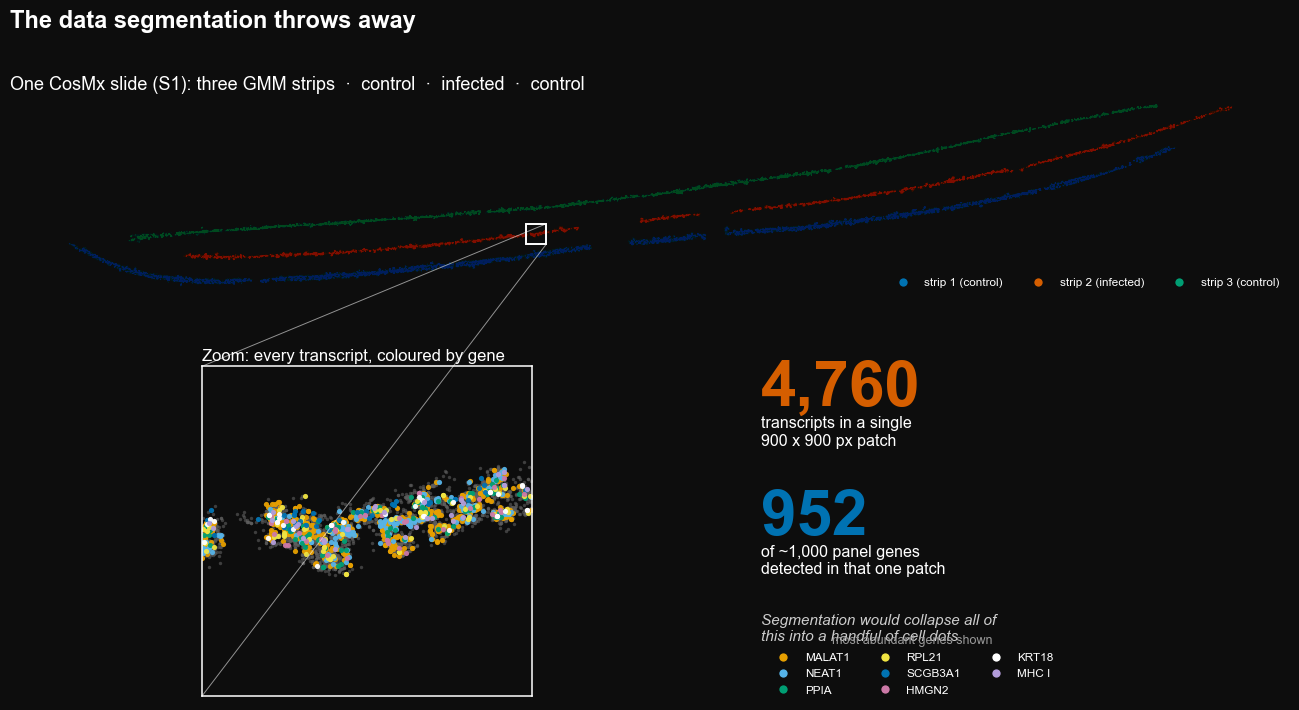

In [3]:
df = pd.read_parquet(DATA / "s1_all_strips_cleaned.parquet")
keep = (~df.is_noise) & (~df.is_small_cluster.fillna(False)) & (~df.manually_excluded.fillna(False))
k = df[keep].copy(); k["Hc"] = k.y_global_px_transformed.values; k["Vc"] = k.x_global_px_transformed.values
s2 = k[k.strip == "strip_2"]
hb, xe, ye = np.histogram2d(s2.Hc, s2.Vc, bins=[np.arange(s2.Hc.min(), s2.Hc.max(), 450), np.arange(s2.Vc.min(), s2.Vc.max(), 450)])
ii, jj = np.unravel_index(hb.argmax(), hb.shape); Hcen, Vcen = (xe[ii]+xe[ii+1])/2, (ye[jj]+ye[jj+1])/2
S = 900; H0, H1, V0, V1 = Hcen-S/2, Hcen+S/2, Vcen-S/2, Vcen+S/2
win = k[(k.Hc > H0) & (k.Hc < H1) & (k.Vc > V0) & (k.Vc < V1)]
topg = win.target.value_counts().head(8).index.tolist()
pal = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#CC79A7", "#FFFFFF", "#B39DDB"]
gc = dict(zip(topg, pal))

fig = plt.figure(figsize=(13.33, 7.5), facecolor=BG)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.55], width_ratios=[1.35, 1], hspace=0.24, wspace=0.06, left=0.02, right=0.98, top=0.86, bottom=0.05)
axA = fig.add_subplot(gs[0, :]); axA.set_facecolor(BG)
for st, c in STRIP.items():
    m = k.strip.values == st
    axA.scatter(k.Hc.values[m], k.Vc.values[m], s=0.03, c=c, alpha=0.3, lw=0, rasterized=True)
axA.add_patch(Rectangle((H0, V0), S, S, fill=False, ec="white", lw=1.4))
axA.set_aspect("equal"); axA.set_xticks([]); axA.set_yticks([])
for sp in axA.spines.values(): sp.set_visible(False)
axA.set_title("One CosMx slide (S1): three GMM strips  ·  control  ·  infected  ·  control", color="white", fontsize=13, loc="left", pad=4)
axA.legend(handles=[Line2D([0],[0],marker="o",color=BG,markerfacecolor=c,markersize=7,label=STRIP_LABEL[s]) for s,c in STRIP.items()],
           loc="lower right", frameon=False, labelcolor="white", fontsize=8.5, ncol=3, bbox_to_anchor=(1.0,-0.02))
axB = fig.add_subplot(gs[1, 0]); axB.set_facecolor(BG)
o = win[~win.target.isin(topg)]
axB.scatter(o.Hc, o.Vc, s=6, c="#606060", alpha=.6, lw=0, rasterized=True)
for g in topg:
    m = win.target == g
    axB.scatter(win.Hc[m], win.Vc[m], s=14, c=gc[g], alpha=.95, lw=0, rasterized=True)
axB.set_xlim(H0, H1); axB.set_ylim(V0, V1); axB.set_aspect("equal"); axB.set_xticks([]); axB.set_yticks([])
for sp in axB.spines.values(): sp.set_color("white"); sp.set_linewidth(1.1)
axB.set_title("Zoom: every transcript, coloured by gene", color="white", fontsize=12, loc="left", pad=4)
for (xw, yw), (xb, yb) in [((H1, V1), (0, 1)), ((H1, V0), (0, 0))]:
    fig.add_artist(ConnectionPatch(xyA=(xw, yw), coordsA=axA.transData, xyB=(xb, yb), coordsB=axB.transAxes, color="white", lw=0.7, alpha=0.55))
axC = fig.add_subplot(gs[1, 1]); axC.set_facecolor(BG); axC.axis("off")
axC.text(0, 1.02, f"{len(win):,}", color=VERM, fontsize=46, fontweight="bold", va="top")
axC.text(0, 0.85, "transcripts in a single\n900 x 900 px patch", color="white", fontsize=11.5, va="top")
axC.text(0, 0.63, str(win.target.nunique()), color=BLUE, fontsize=46, fontweight="bold", va="top")
axC.text(0, 0.46, "of ~1,000 panel genes\ndetected in that one patch", color="white", fontsize=11.5, va="top")
axC.text(0, 0.25, "Segmentation would collapse all of\nthis into a handful of cell dots.", color="#ccc", fontsize=11, va="top", style="italic")
lg = axC.legend(handles=[Line2D([0],[0],marker="o",color=BG,markerfacecolor=gc[g],markersize=7,label=g) for g in topg],
                loc="lower left", frameon=False, fontsize=8.5, ncol=3, bbox_to_anchor=(0,-0.03), title="most abundant genes shown", title_fontsize=9)
for t in lg.get_texts(): t.set_color("white")
lg.get_title().set_color("#999")
fig.suptitle("The data segmentation throws away", color="white", fontsize=17, fontweight="bold", x=0.02, ha="left", y=0.965)
finish(fig, "data_atlas")

## 3: The statistic, one stage at a time
Edge correction, bivariate K, the L-transform, the permutation envelope, and SES. Formulae match the methods.

saved STIPPLE_maths.png


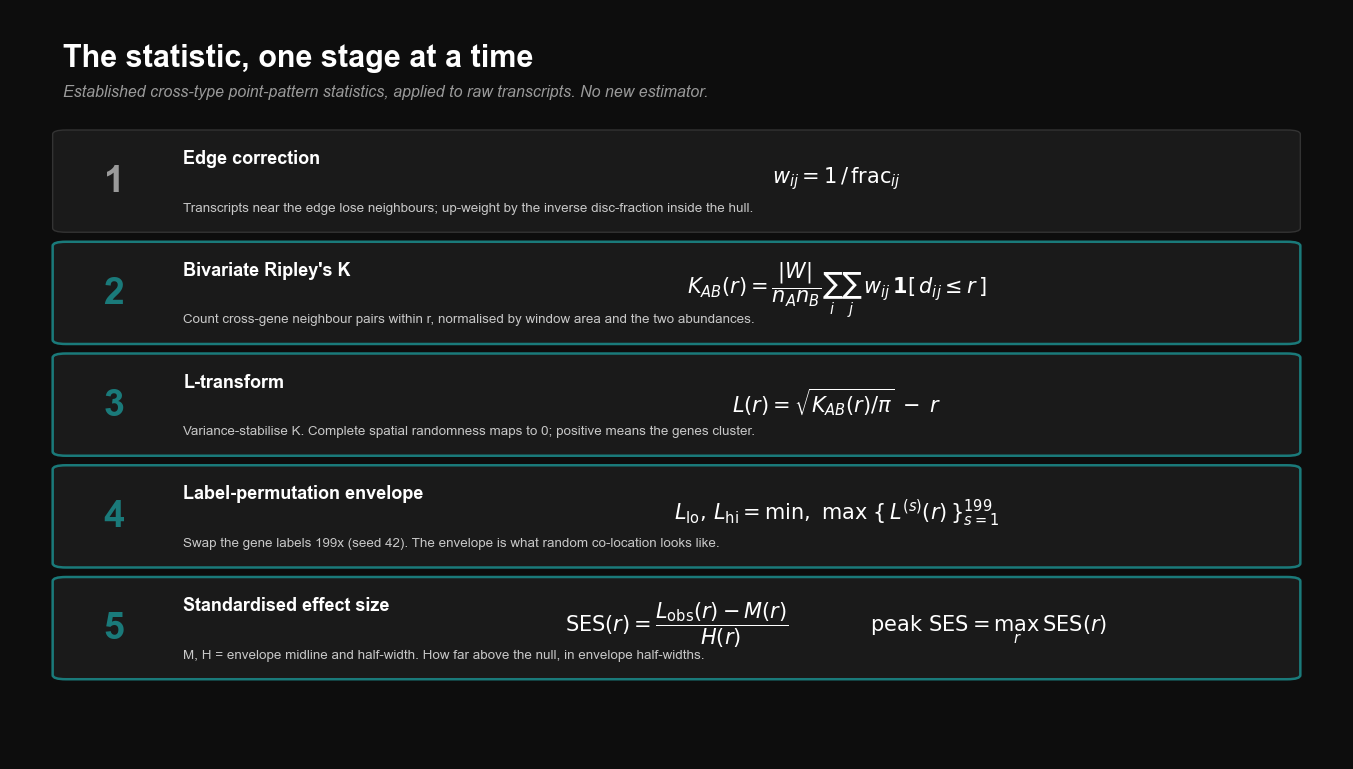

In [4]:
stages = [
    ("1", "Edge correction", r"$w_{ij} = 1\,/\,\mathrm{frac}_{ij}$",
     "Transcripts near the edge lose neighbours; up-weight by the inverse disc-fraction inside the hull.", False),
    ("2", "Bivariate Ripley's K", r"$K_{AB}(r)=\dfrac{|W|}{n_A n_B}\sum_{i}\sum_{j}\, w_{ij}\,\mathbf{1}[\,d_{ij}\leq r\,]$",
     "Count cross-gene neighbour pairs within r, normalised by window area and the two abundances.", True),
    ("3", "L-transform", r"$L(r)=\sqrt{K_{AB}(r)/\pi}\;-\;r$",
     "Variance-stabilise K. Complete spatial randomness maps to 0; positive means the genes cluster.", True),
    ("4", "Label-permutation envelope", r"$L_{\mathrm{lo}},\,L_{\mathrm{hi}} = \min,\ \max\;\{\,L^{(s)}(r)\,\}_{s=1}^{199}$",
     "Swap the gene labels 199x (seed 42). The envelope is what random co-location looks like.", True),
    ("5", "Standardised effect size", r"$\mathrm{SES}(r)=\dfrac{L_{\mathrm{obs}}(r)-M(r)}{H(r)}\qquad\qquad \mathrm{peak\ SES}=\max_r\,\mathrm{SES}(r)$",
     "M, H = envelope midline and half-width. How far above the null, in envelope half-widths.", True),
]
fig = plt.figure(figsize=(13.33, 7.5), facecolor=BG)
ax = fig.add_axes([0, 0, 1, 1]); ax.set_facecolor(BG); ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
ax.text(4, 95.5, "The statistic, one stage at a time", color=WHITE, fontsize=22, fontweight="bold", va="top")
ax.text(4, 90, "Established cross-type point-pattern statistics, applied to raw transcripts. No new estimator.", color=GREY, fontsize=11.5, va="top", style="italic")
top = 85.0; h = 14.6; gap = 1.3; y = top
for num, name, formula, note, core in stages:
    y0 = y - h; ec = TEAL if core else FAINT
    ax.add_patch(FancyBboxPatch((3.5, y0), 93, h-gap, boxstyle="round,pad=0.3,rounding_size=1.0", fc=CARD, ec=ec, lw=1.8 if core else 1.0, mutation_aspect=0.55))
    cy = y0 + (h-gap)/2
    ax.text(7.8, cy, num, color=TEAL if core else GREY, fontsize=27, fontweight="bold", ha="center", va="center")
    ax.text(13, y0+(h-gap)-2.4, name, color=WHITE, fontsize=13, fontweight="bold", va="top")
    ax.text(13, y0+2.3, note, color=MUTED, fontsize=9.6, va="bottom")
    ax.text(62, cy+0.5, formula, color=WHITE, fontsize=15, ha="center", va="center")
    y = y0 - 0.3
finish(fig, "maths")

## 4: Bivariate Ripley schematic
Count gene-B transcripts within radius r of each gene-A transcript. Transparent background for slide overlay.

saved STIPPLE_ripley_schematic.png


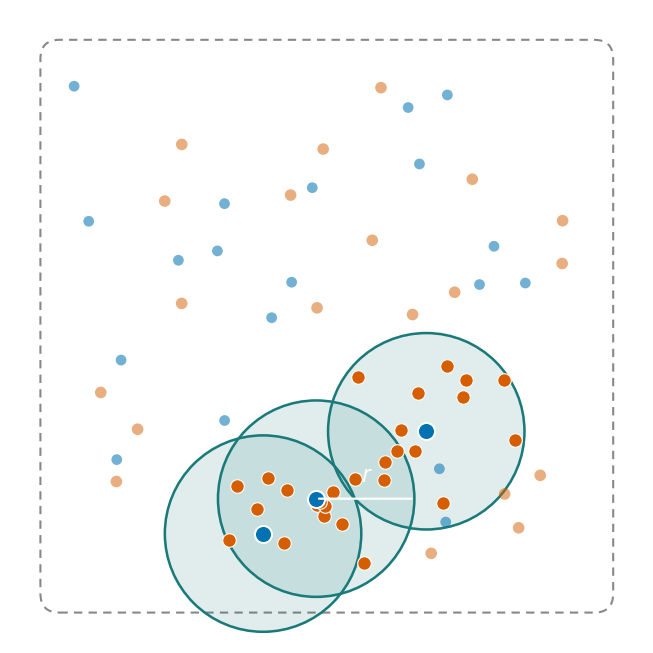

In [5]:
rng = np.random.default_rng(3)
A = rng.uniform(1.0, 9.0, size=(22, 2)); B = rng.uniform(1.0, 9.0, size=(30, 2))
anchors = A[[3, 9, 15]]
B = np.vstack([B, np.repeat(anchors, 6, axis=0) + rng.normal(0, 0.5, size=(18, 2))])
fig = plt.figure(figsize=(6.6, 6.6)); ax = fig.add_axes([0.02, 0.02, 0.96, 0.96])
ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.add_patch(FancyBboxPatch((0.5, 0.5), 9, 9, boxstyle="round,pad=0.02,rounding_size=0.3", fill=False, ec="#888", lw=1.5, linestyle=(0, (4, 3))))
r = 1.55; focal = A[[3, 9, 15]]
for fx, fy in focal:
    ax.add_patch(Circle((fx, fy), r, fc=TEAL, ec=TEAL, lw=1.8, alpha=0.13))
    ax.add_patch(Circle((fx, fy), r, fill=False, ec=TEAL, lw=1.8))
inside = np.zeros(len(B), bool)
for fx, fy in focal: inside |= (np.hypot(B[:, 0]-fx, B[:, 1]-fy) <= r)
ax.scatter(B[~inside, 0], B[~inside, 1], s=70, c=VERM, alpha=.5, edgecolors="none", zorder=3)
ax.scatter(B[inside, 0], B[inside, 1], s=95, c=VERM, edgecolors="white", linewidths=.8, zorder=4)
ax.scatter(A[:, 0], A[:, 1], s=60, c=BLUE, alpha=.55, edgecolors="none", zorder=3)
ax.scatter(focal[:, 0], focal[:, 1], s=150, c=BLUE, edgecolors="white", linewidths=1.4, zorder=5)
fx, fy = focal[0]
ax.annotate("", xy=(fx+r, fy), xytext=(fx, fy), arrowprops=dict(arrowstyle="-", color="white", lw=1.6), zorder=6)
ax.text(fx+r/2, fy+0.28, "r", color="white", fontsize=17, ha="center", fontstyle="italic", zorder=6)
fig.savefig(FIG / "STIPPLE_ripley_schematic.png", dpi=200, transparent=True)
print("saved STIPPLE_ripley_schematic.png"); plt.show()

## Load the screen output and compute SES (for figures 5-7)

In [6]:
d = pd.concat([pd.read_parquet(ROOT/"results"/"lr_panel_results.parquet"),
               pd.read_parquet(ROOT/"results"/"lr_panel_results_v2.parquet")], ignore_index=True)
Rv = np.load(ROOT/"results"/"lr_panel_results.parquet.r_vals.npy")
def sesc(r):
    lo, hi, ob = np.array(r.l_lo, float), np.array(r.l_hi, float), np.array(r.l_obs, float)
    Hh = np.where((hi-lo)/2 == 0, np.nan, (hi-lo)/2); return (ob-(hi+lo)/2)/Hh
Smat = np.nan_to_num(np.vstack([sesc(r) for _, r in d.iterrows()]), nan=0.0)
d["peak_ses"] = np.nanmax(Smat, axis=1); d["r_at_peak"] = Rv[np.nanargmax(Smat, axis=1)]
d["pair"] = d.ligand + " x " + d.receptor
piv = d.groupby(["pair", "strip"]).peak_ses.max().unstack("strip")[["strip_1", "strip_2", "strip_3"]]
piv["delta"] = piv["strip_2"] - (piv["strip_1"] + piv["strip_3"]) / 2
print("tests:", len(d), "| unique pairs:", len(piv))

tests: 614 | unique pairs: 203


## 5: Heatmap: immune pairs elevate in the infected strip

saved STIPPLE_heatmap.png


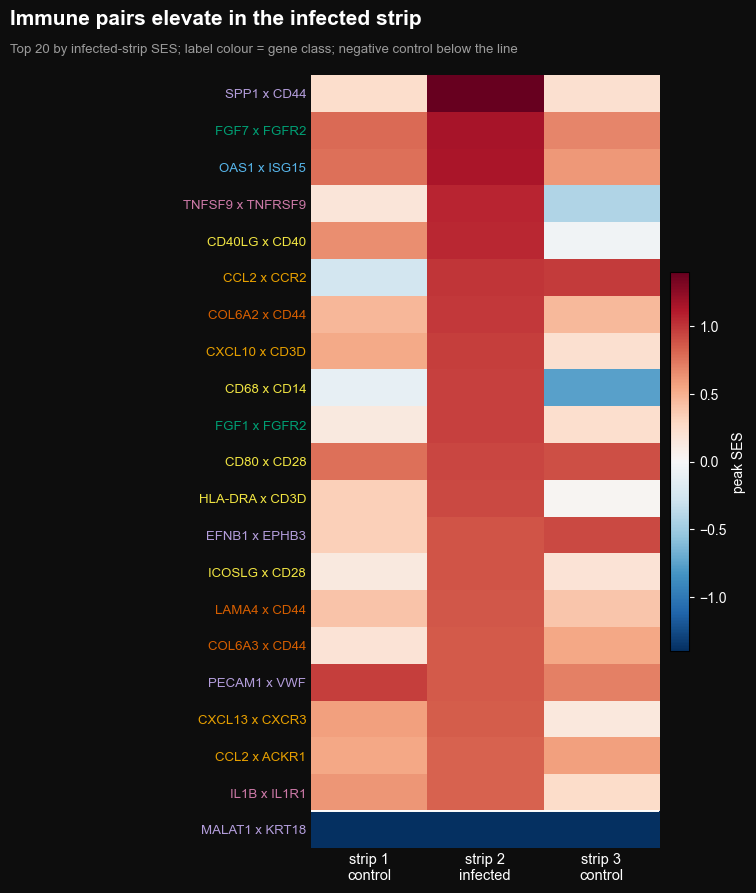

In [7]:
top = piv.sort_values("strip_2", ascending=False).head(20)
ctrl = piv.loc[[p for p in ["KRT8 x SCGB3A1", "MALAT1 x KRT18"] if p in piv.index]]
M = pd.concat([top, ctrl])[["strip_1", "strip_2", "strip_3"]]
fig = plt.figure(figsize=(8.6, 9.2), facecolor=BG)
ax = fig.add_axes([0.40, 0.07, 0.44, 0.84]); ax.set_facecolor(BG)
im = ax.imshow(M.values, cmap="RdBu_r", vmin=-1.4, vmax=1.4, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["strip 1\ncontrol", "strip 2\ninfected", "strip 3\ncontrol"], color="white", fontsize=10.5)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=9.5)
for t, pr in zip(ax.get_yticklabels(), M.index): t.set_color(CLSCOL[cls(pr.split(" x ")[0])])
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.axhline(len(top)-0.5, color="white", lw=1.4)
cb = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03); cb.set_label("peak SES", color="white")
cb.ax.yaxis.set_tick_params(color="white"); plt.setp(plt.getp(cb.ax, "yticklabels"), color="white")
fig.text(0.05, 0.965, "Immune pairs elevate in the infected strip", color=WHITE, fontsize=15, fontweight="bold")
fig.text(0.05, 0.935, "Top 20 by infected-strip SES; label colour = gene class; negative control below the line", color=GREY, fontsize=9.5)
finish(fig, "heatmap")

## 6: Control to infected: the co-localisation shift

The infection differential shown per pair as a **dumbbell**: mean control SES (grey) connected to infected-strip
SES (coloured), so the shift is explicit. Immune and infection pairs jump toward the envelope edge; the negative
control stays strongly negative below the line. Clearer and more honest than a sparse graph.

saved STIPPLE_shift.png


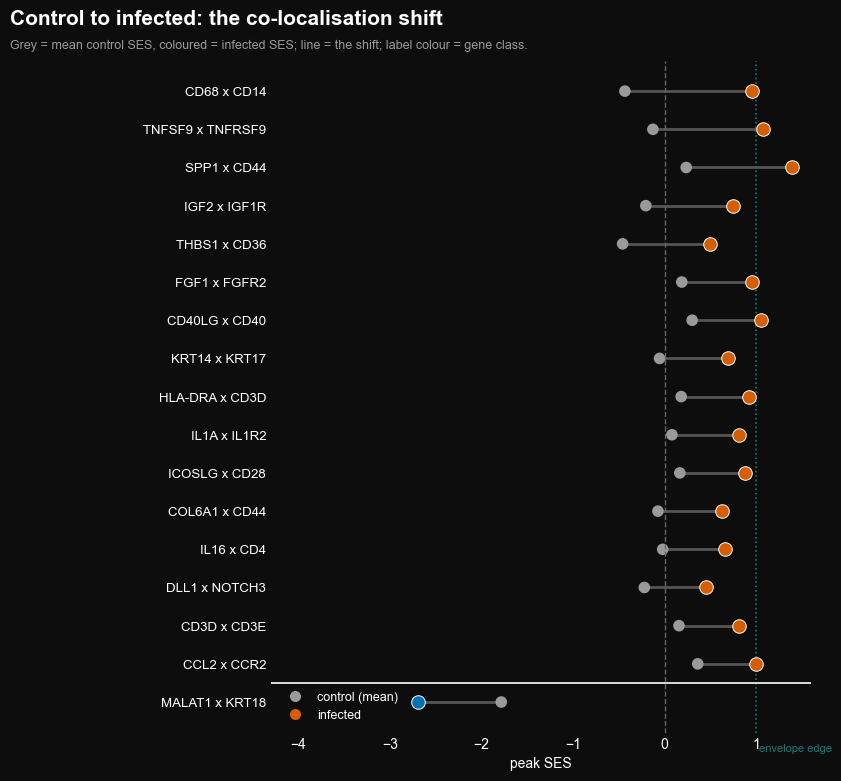

In [8]:
piv["ctrl"] = (piv.strip_1 + piv.strip_3) / 2
piv["inf"] = piv.strip_2
sel = piv[piv.strip_2 > 0.4].sort_values("delta").tail(16)
ref = piv.loc[[p for p in ["MALAT1 x KRT18"] if p in piv.index]]
rows = pd.concat([ref, sel])

fig = plt.figure(figsize=(9, 8), facecolor=BG)
ax = fig.add_axes([0.34, 0.08, 0.60, 0.84]); ax.set_facecolor(BG)
for i, (pr, r) in enumerate(rows.iterrows()):
    ax.plot([r.ctrl, r["inf"]], [i, i], color="#555", lw=2, zorder=1)
    ax.scatter(r.ctrl, i, s=70, c=GREY, zorder=2, edgecolors="none")
    ax.scatter(r["inf"], i, s=95, c=VERM if r.delta > 0 else BLUE, zorder=3, edgecolors="white", linewidths=0.7)
ax.axvline(0, color="#666", ls="--", lw=1)
ax.axvline(1, color=TEAL, ls=":", lw=1.2); ax.text(1.03, -1.3, "envelope edge", color=TEAL, fontsize=8)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows.index, fontsize=9.5)
for t, pr in zip(ax.get_yticklabels(), rows.index):
    t.set_color(CLSCOL[cls(pr.split(" x ")[0])])
ax.axhline(len(ref) - 0.5, color="#fff", lw=1.2)
ax.set_xlabel("peak SES", color="white"); ax.tick_params(colors="white", length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlim(-4.3, 1.6)
fig.text(0.05, 0.965, "Control to infected: the co-localisation shift", color=WHITE, fontsize=15, fontweight="bold")
fig.text(0.05, 0.935, "Grey = mean control SES, coloured = infected SES; line = the shift; label colour = gene class.",
         color=GREY, fontsize=9)
lg = ax.legend(handles=[Line2D([0], [0], marker="o", color=BG, markerfacecolor=GREY, markersize=9, label="control (mean)"),
                        Line2D([0], [0], marker="o", color=BG, markerfacecolor=VERM, markersize=9, label="infected")],
               loc="lower left", frameon=False, fontsize=9)
for t in lg.get_texts(): t.set_color("white")
finish(fig, "shift")

## 7: The hero in profile: SPP1 x CD44 across the strips

Observed L(r) vs the permutation envelope for the single strict hit. It rises above the null **only in the
infected strip** (seven consecutive radii); both controls stay inside. The envelope already accounts for
abundance, so this is the abundance-corrected, infection-specific evidence that a raw spatial scatter cannot
give (raw nearest-neighbour distances are actually shorter in a control strip, because it has more CD44).

saved STIPPLE_hero_profile.png


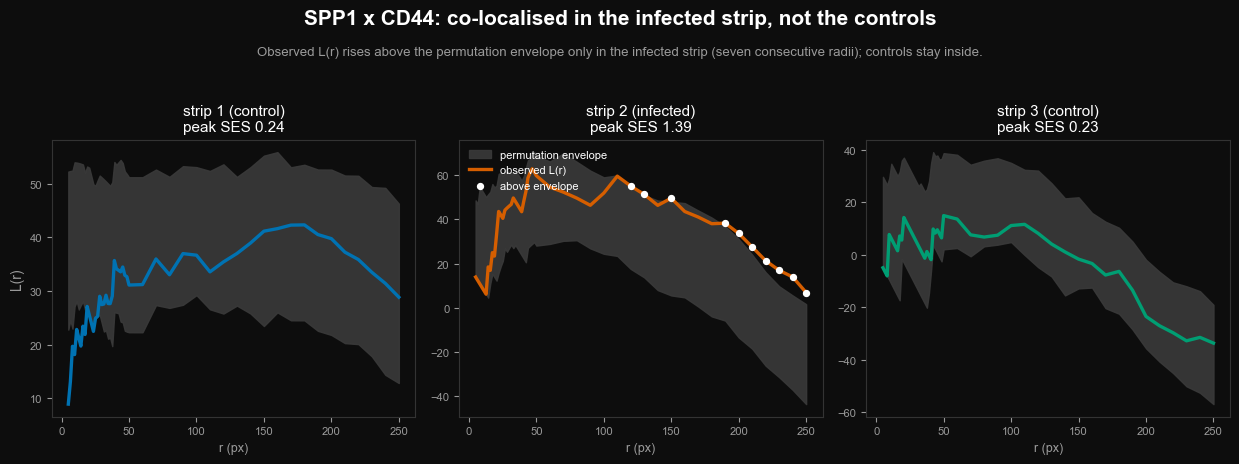

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.6), facecolor=BG)
for ax, st in zip(axs, ["strip_1", "strip_2", "strip_3"]):
    row = d[(d.ligand == "SPP1") & (d.receptor == "CD44") & (d.strip == st)].iloc[0]
    lo, hi, ob = np.array(row.l_lo, float), np.array(row.l_hi, float), np.array(row.l_obs, float)
    Hh = np.where((hi - lo) / 2 == 0, np.nan, (hi - lo) / 2)
    peak = np.nanmax((ob - (hi + lo) / 2) / Hh)
    ax.set_facecolor(BG)
    ax.fill_between(Rv, lo, hi, color="#3a3a3a", alpha=0.9, label="permutation envelope")
    ax.plot(Rv, ob, color=STRIP[st], lw=2.4, label="observed L(r)")
    exc = ob > hi
    if exc.any():
        ax.scatter(Rv[exc], ob[exc], s=18, c="white", zorder=5, label="above envelope")
    ax.set_title(f"{STRIP_LABEL[st]}\npeak SES {peak:.2f}", color="white", fontsize=11)
    ax.tick_params(colors=GREY, labelsize=8)
    for s in ax.spines.values(): s.set_color("#333")
    ax.set_xlabel("r (px)", color=GREY, fontsize=9)
axs[0].set_ylabel("L(r)", color=GREY)
axs[1].legend(frameon=False, fontsize=8, labelcolor="white", loc="upper left")
fig.suptitle("SPP1 x CD44: co-localised in the infected strip, not the controls", color=WHITE, fontsize=15, fontweight="bold", y=1.0)
fig.text(0.5, 0.90, "Observed L(r) rises above the permutation envelope only in the infected strip (seven consecutive radii); controls stay inside.",
         color=GREY, fontsize=9.5, ha="center")
plt.tight_layout(rect=[0, 0, 1, 0.9])
finish(fig, "hero_profile")